# PINNs: ODE damped oscillator

$$
\begin{cases}
    0 = \ddot{x} + 2\zeta\omega.\dot{x} + \omega^2.x \\
    x(0) = x_0 \\
    \dot{x}(0) = 0
\end{cases}
$$

Solution: (underdamped, $\zeta < 1$)



In [1]:
# imports
# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [2]:


# Define the PINN model
class PINN(nn.Module):

    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

        # equation parameters
        self.ZETTA = 0.2
        self.W = 10

    def forward(self, t):
        return self.net(t)

    # Define the Poisson equation loss function
    def damped_oscillatior_loss(self, t):
        # alias to simplify notation
        # parameters
        ZETTA = self.ZETTA
        W = self.W
        
        # compute estimation for position
        x = self.forward(t)

        # compute derivatives of first and second order
        x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]

        # residue for damped oscillator
        f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2
        return torch.mean(f)
    
    def boundary_condition_loss(self, t0, x0, dx0):

        # estimation for x0
        x0_est = self.forward(t0)

        # residue for x0
        initial_conditions = (x0_est - x0)**2

        # estimation for dx0
        dx0_est = torch.autograd.grad(x0_est, t0, grad_outputs=torch.ones_like(x0_est), create_graph=True)[0]

        # residue for dx0
        initial_conditions_der = (dx0_est - dx0)**2


        return torch.mean(initial_conditions) + torch.mean(initial_conditions_der)

In [3]:
# Training data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 2]
t.requires_grad = True

# initial conditions
t0 = torch.tensor([0.0], requires_grad=True)
x0 = torch.tensor([1.0], requires_grad=True)
dx0 = torch.tensor([0.0], requires_grad=True)

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

# loss tracking
losses = []

# Training loop
epochs = 60000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = model.damped_oscillatior_loss(t) + model.boundary_condition_loss(t0, x0, dx0)
    
    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/60000], Loss: 107.52355194091797
Epoch [1000/60000], Loss: 0.9971107244491577
Epoch [2000/60000], Loss: 0.9969961643218994
Epoch [3000/60000], Loss: 0.9969423413276672
Epoch [4000/60000], Loss: 0.9969173073768616
Epoch [5000/60000], Loss: 0.996846079826355
Epoch [6000/60000], Loss: 0.9968346357345581
Epoch [7000/60000], Loss: 0.996822714805603
Epoch [8000/60000], Loss: 0.9968047142028809
Epoch [9000/60000], Loss: 0.9976140856742859
Epoch [10000/60000], Loss: 0.9967589378356934
Epoch [11000/60000], Loss: 0.9967027306556702
Epoch [12000/60000], Loss: 0.9966641664505005
Epoch [13000/60000], Loss: 0.9970065355300903
Epoch [14000/60000], Loss: 0.9966598749160767
Epoch [15000/60000], Loss: 0.9965628981590271
Epoch [16000/60000], Loss: 0.9964244961738586
Epoch [17000/60000], Loss: 0.9963481426239014
Epoch [18000/60000], Loss: 0.9960517287254333
Epoch [19000/60000], Loss: 0.9964035153388977
Epoch [20000/60000], Loss: 0.9959226846694946
Epoch [21000/60000], Loss: 0.9954399466514587
Epo

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


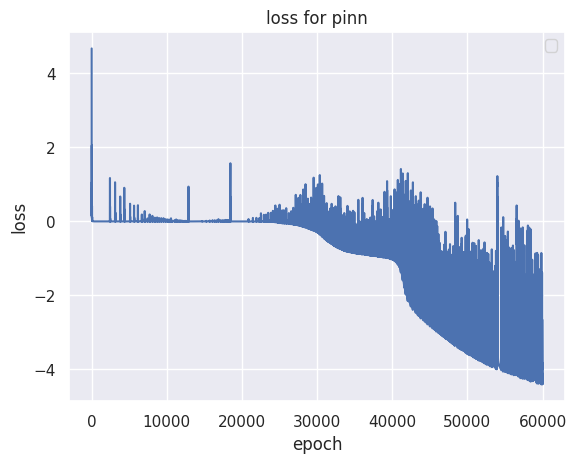

In [4]:
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('log-loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


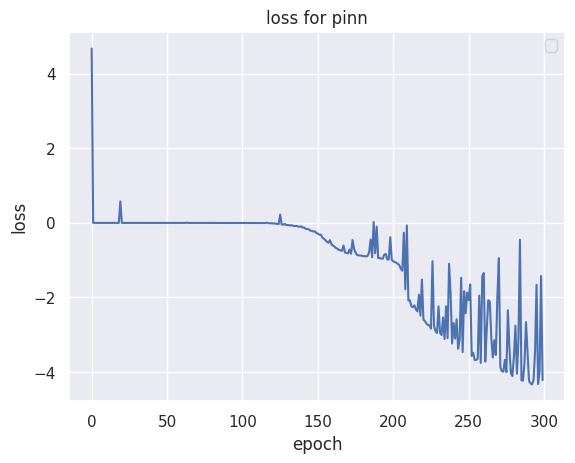

In [5]:
plt.figure()
plt.plot(losses[::200])
plt.xlabel('epoch')
plt.ylabel('log-loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

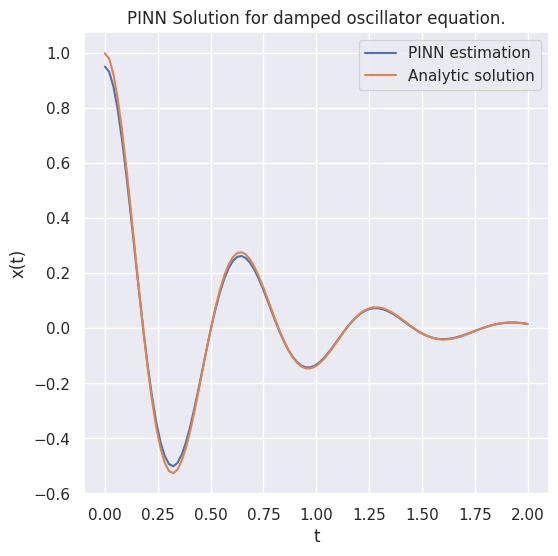

In [6]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(6,6))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

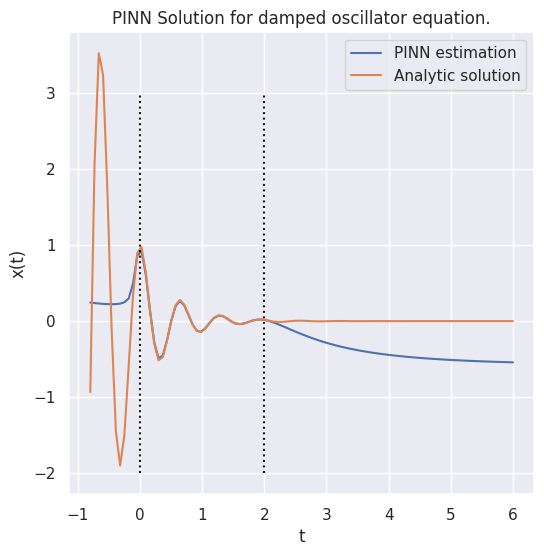

In [7]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 4*torch.linspace(-.2, 1.5, 100).reshape(-1, 1)
x_test = model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(6,6))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.vlines([0, 2], [-2, -2], [3, 3], colors=["k", "k"], linestyles="dotted")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()